In [12]:
# HW11 STAT 604 Duncan Newman

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import numpy as np

# Problem 1
fastfood = pd.read_csv("fastfood.csv")

# Inspect columns
print(fastfood.head())
print(fastfood.columns)

        State  Restaurants  Obesity
0     Alabama          6.3     35.7
1      Alaska          2.6     31.4
2     Arizona          4.6     29.0
3    Arkansas          4.7     35.7
4  California          3.6     25.0
Index(['State', 'Restaurants', 'Obesity'], dtype='object')


a. The correlation would more than likely be positive ie. the more fast food, the higher the obesity rate

b. The explanatory would be fst food per capita and reponse would be obesity rate.

In [13]:
# 1c

corr = fastfood['Restaurants'].corr(fastfood['Obesity'])
print("Correlation:", corr)

Correlation: 0.5176418718066557


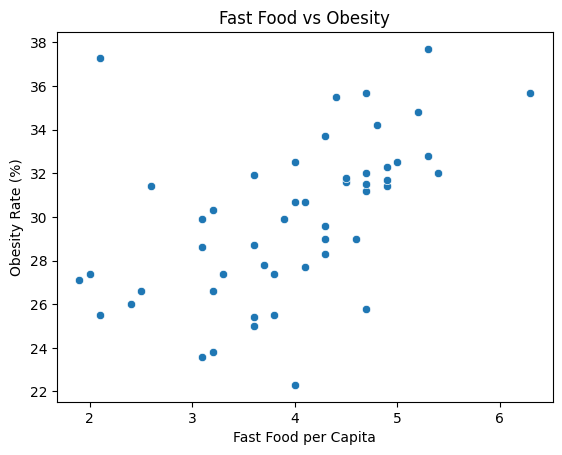

In [14]:
# 1d

plt.figure()
sns.scatterplot(x='Restaurants', y='Obesity', data=fastfood)
plt.xlabel("Fast Food per Capita")
plt.ylabel("Obesity Rate (%)")
plt.title("Fast Food vs Obesity")
plt.show()

In [15]:
# 1f

X = fastfood['Restaurants']
y = fastfood['Obesity']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Obesity   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     17.57
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           0.000118
Time:                        21:09:16   Log-Likelihood:                -127.13
No. Observations:                  50   AIC:                             258.3
Df Residuals:                      48   BIC:                             262.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          22.4026      1.851     12.101      

In [16]:
# 1e

fastfood['residuals'] = model.resid

# Define outliers (e.g., residual > 2 std)
threshold = 2 * fastfood['residuals'].std()
clean_data = fastfood[abs(fastfood['residuals']) < threshold]

# Refit model
X_clean = sm.add_constant(clean_data['Restaurants'])
y_clean = clean_data['Obesity']

model_clean = sm.OLS(y_clean, X_clean).fit()

print(model_clean.summary())

                            OLS Regression Results                            
Dep. Variable:                Obesity   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     40.17
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           8.99e-08
Time:                        21:09:16   Log-Likelihood:                -110.85
No. Observations:                  48   AIC:                             225.7
Df Residuals:                      46   BIC:                             229.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          20.4670      1.537     13.313      

In [17]:
# 1g

virginia_value = 4.3
pred = model_clean.predict([1, virginia_value])
print("Predicted obesity rate for Virginia:", pred[0])

Predicted obesity rate for Virginia: 30.641665572786792


In [18]:
# Problem 2

highway = pd.read_csv("highwaysafety.csv")

print(highway.head())
print(highway.columns)

    mph   dist
0  25.0   37.4
1  35.0   57.7
2  60.0  337.6
3  45.0  142.5
4  50.0  182.4
Index(['mph', 'dist'], dtype='object')


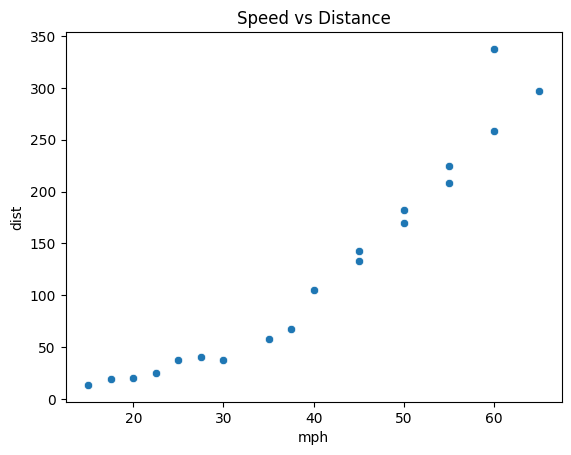

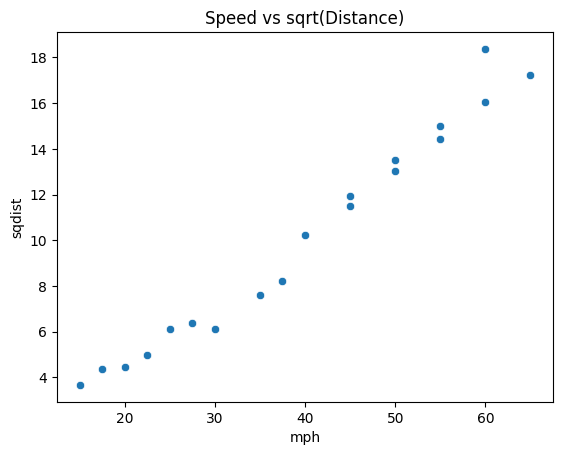

In [19]:
# 2a
plt.figure()
sns.scatterplot(x='mph', y='dist', data=highway)
plt.title("Speed vs Distance")
plt.show()

# Square root transformation
highway['sqdist'] = np.sqrt(highway['dist'])

plt.figure()
sns.scatterplot(x='mph', y='sqdist', data=highway)
plt.title("Speed vs sqrt(Distance)")
plt.show()

In [20]:
# 2b

X = highway['mph']
y = highway['sqdist']

X = sm.add_constant(X)
model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 sqdist   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     604.6
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.00e-14
Time:                        21:09:17   Log-Likelihood:                -21.959
No. Observations:                  19   AIC:                             47.92
Df Residuals:                      17   BIC:                             49.81
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6955      0.517     -3.276      0.0

In [29]:
# 2c

from scipy import stats

# Extract slope and standard error (use column name for safety)
slope = model2.params['mph']
std_err = model2.bse['mph']

# Hypothesized value
beta0 = 0.27

# Test statistic
t_stat = (slope - beta0) / std_err

# Degrees of freedom
df = len(highway) - 2

# Two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print("Slope estimate:", slope)
print("Standard error:", std_err)
print("t-statistic:", t_stat)
print("p-value:", p_value)

# Decision at alpha = 0.01
alpha = 0.01
if p_value < alpha:
    print("Reject H0: The slope is significantly different from 0.27")
else:
    print("Fail to reject H0: Not enough evidence that slope differs from 0.27")



Slope estimate: 0.2986920320570884
Standard error: 0.012147958656665946
t-statistic: 2.361880943786732
p-value: 0.030375297378354427
Fail to reject H0: Not enough evidence that slope differs from 0.27


In [30]:
 # 2d

mph_val = 52

# Predict sqrt(dist)
pred_sq = model2.predict([1, mph_val])[0]

# Convert back
pred_dist = pred_sq ** 2

print("Predicted stopping distance:", pred_dist)

Predicted stopping distance: 191.44949376386532
